**Import Inpendencies**

In [1]:
!pip install -q natsort

In [27]:
# import cv2
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from tqdm import tqdm
import random
import os

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model
from tensorflow.keras import optimizers
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Prepare Data

In [3]:
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
mapping_label = {class_name: i for i, class_name in enumerate(class_names)}
mapping_label

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [4]:
# def read_image(image_path, resize):
#     image = cv2.imread(image_path)
#     image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#     image = cv2.resize(image, resize)

#     return image

def read_image(image_path, resize):
    image = Image.open(image_path)
    image = image.resize(resize)
    image_array = np.array(image)
    
    return image_array

def load_data(dataset_path, resize):
    labels = []
    images = []
    i = 0

    for root, _, ims in os.walk(dataset_path):
        if ims:
            label = root.split(os.sep)[-1]
            for im in tqdm(natsorted(ims), desc=f"Uploading class {label}"):
                if im.endswith(".jpg"):
                    image = read_image(os.path.join(root, im), resize)
                    images.append(image)
                    labels.append(mapping_label[label])

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)
    # dtype = float32 because model will process better
    # dtype = int32 is suit for labels

    print(f"Loaded {dataset_path} -------------------------------")

    return images, labels

In [5]:
TRAIN_PATH = "dataset/seg"
TEST_PATH = "dataset/seg_test"
IMAGE_SIZE = (150, 150)

images_train, labels_train = load_data(TRAIN_PATH, IMAGE_SIZE)
images_test, labels_test = load_data(TEST_PATH, IMAGE_SIZE)

Uploading class buildings:   0%|          | 0/437 [00:00<?, ?it/s]

Loaded dataset/seg -------------------------------


Uploading class forest: 100%|██████████| 474/474 [00:00<00:00, 2622.38it/s]


Loaded dataset/seg_test -------------------------------


In [6]:
# checking imbalance
def classes_count(labels):
    count = {}
    for i in (labels):
        count[i] = count.get(i , 0) + 1
    return count

classes_count(labels_train)

{2: 2404, 0: 2191, 4: 2274, 5: 2382, 3: 2512, 1: 2271}

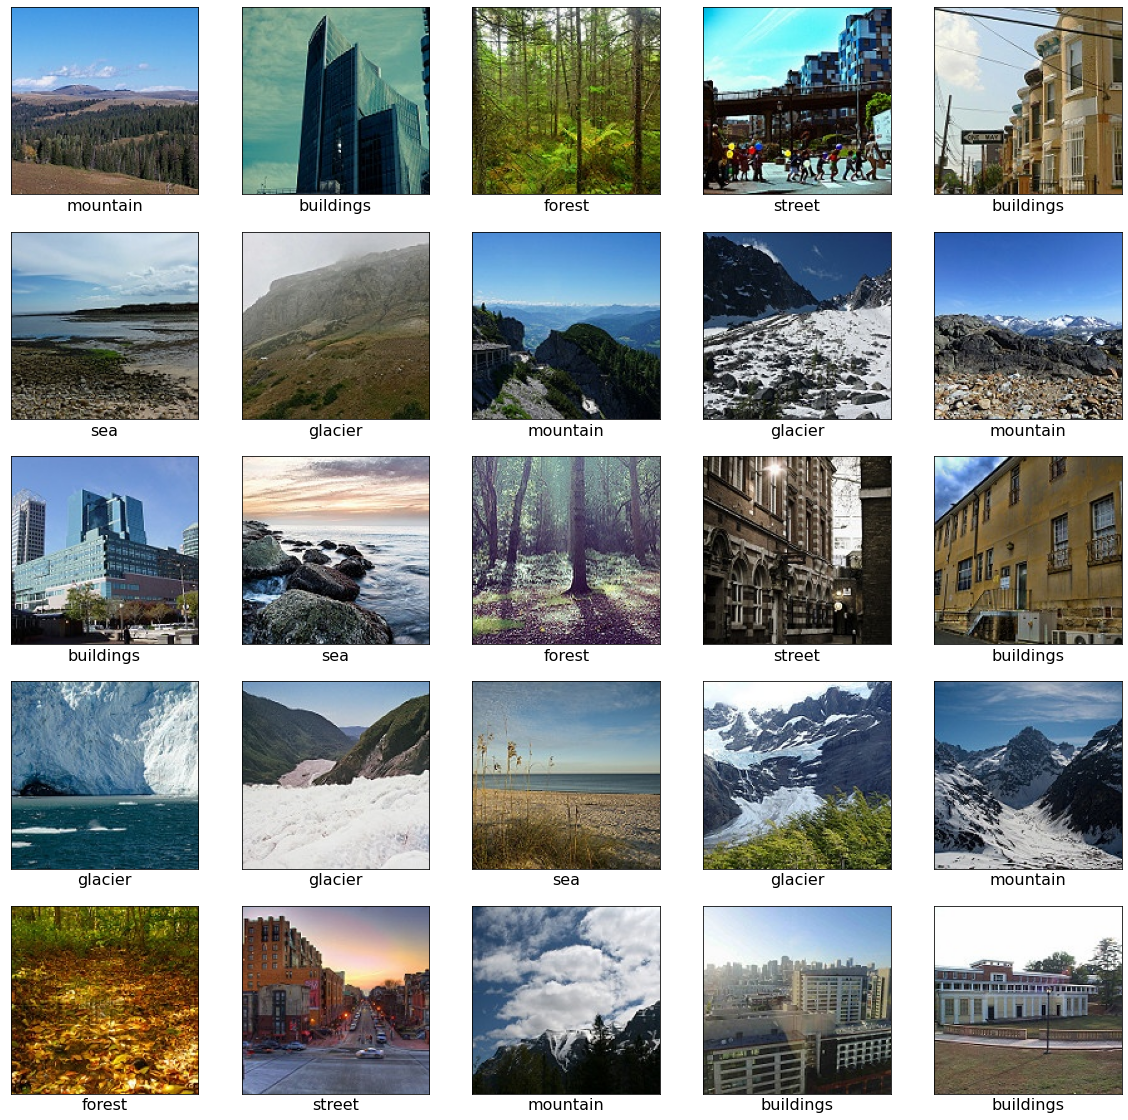

In [12]:
def display_images(images, labels):
    plt.figure(figsize=(20, 20))
    plt.title("Image from dataset")
    for i, j in zip(random.sample(range(1, len(images)), 25), range(25)):
        plt.subplot(5, 5, j + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i].astype(np.uint8))
        plt.xlabel(class_names[labels[i]], fontsize=16)
    plt.show()

display_images(images_train, labels_train)

In [7]:
#Visualize accuracy and loss in training process
def plot_accuracy_loss(training_process):
    #plot accuracy
    plt.subplot(221)
    plt.plot(training_process.history['accuracy'], 'bo--', label = "acc")
    plt.plot(training_process.history['val_accuracy'], 'ro--', label = "val_acc")
    plt.title("train_acc vs val_acc")
    plt.ylabel("accuracy")
    plt.xlabel("epochs")
    plt.legend()

    #plot loss function
    plt.subplot(222)
    plt.plot(training_process.history['loss'], 'bo--', label = "loss")
    plt.plot(training_process.history['val_loss'], 'ro--', label = "val_loss")
    plt.title("train_loss vs val_loss")
    plt.ylabel("loss")
    plt.xlabel("epochs")
    plt.legend()
    plt.show()

# CNN Model
Reference Paper: https://www.researchgate.net/profile/Md-Anwar-Hossain-6/publication/333191474_Classification_of_Image_using_Convolutional_Neural_Network_CNN/links/5ce0158c299bf14d95a4cf14/Classification-of-Image-using-Convolutional-Neural-Network-CNN.pdf

> I added Dropout after each block to advoid overfitting

In [15]:
# Convert to tensor TF before training

images_tstrain = tf.convert_to_tensor(images_train, dtype=tf.float32)
labels_tstrain = tf.convert_to_tensor(labels_train, dtype=tf.int32)
images_tstest = tf.convert_to_tensor(images_test, dtype=tf.float32)
labels_tstest = tf.convert_to_tensor(labels_test, dtype=tf.int32)
images_tstest.device

'/job:localhost/replica:0/task:0/device:GPU:0'

In [34]:
# Build model
cnn_model = models.Sequential()
cnn_model.add(layers.Input(shape=(150, 150, 3)))

# Block 1
cnn_model.add(layers.Conv2D(32, (5, 5), activation='relu'))
cnn_model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
cnn_model.add(layers.Dropout(0.1)) # Add dropout to avoid overfitting

# Block 2
cnn_model.add(layers.Conv2D(32, (5, 5), activation='relu'))
cnn_model.add(layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)))
cnn_model.add(layers.Dropout(0.1))

# Block 3
cnn_model.add(layers.Conv2D(64, (5, 5), activation='relu'))
cnn_model.add(layers.Dropout(0.1))
cnn_model.add(layers.Flatten())  # Flatten before Fully Connected

# Multi-Layer Perceptron Block
cnn_model.add(layers.Dense(64, activation='relu'))
cnn_model.add(layers.Dropout(0.1))
cnn_model.add(layers.Dense(6, activation='softmax'))

In [35]:
# Compile
opt = optimizers.Adam(learning_rate=.0001)
cnn_model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Save model pipeline
from IPython.display import Image as Display

plot_model(
    cnn_model,
    to_file='cnn_model.png',
    show_shapes=True,
    show_layer_names=False,
    rankdir='TB' # TB for top to bottom, LR for left to right
)

Display(filename="cnn_model.png")

In [37]:
# training model with 10 epoches
cnn_history = cnn_model.fit(images_train, labels_train,
                           shuffle=True,
                           batch_size=256,
                           epochs=20,
                           validation_split=0.1)

Epoch 1/20
50/50 [==============================] - 5s 91ms/step - loss: 10.9595 - accuracy: 0.1940 - val_loss: 1.8102 - val_accuracy: 0.0000e+00
Epoch 2/20
50/50 [==============================] - 4s 83ms/step - loss: 1.7667 - accuracy: 0.2431 - val_loss: 1.9648 - val_accuracy: 0.0036
Epoch 3/20
50/50 [==============================] - 4s 79ms/step - loss: 1.7000 - accuracy: 0.3132 - val_loss: 0.7538 - val_accuracy: 0.8063
Epoch 4/20
50/50 [==============================] - 4s 79ms/step - loss: 1.6349 - accuracy: 0.3626 - val_loss: 0.2958 - val_accuracy: 0.8925
Epoch 5/20
50/50 [==============================] - 4s 79ms/step - loss: 1.5471 - accuracy: 0.4307 - val_loss: 0.5894 - val_accuracy: 0.7778
Epoch 6/20
50/50 [==============================] - 4s 79ms/step - loss: 1.3635 - accuracy: 0.4599 - val_loss: 0.4619 - val_accuracy: 0.8526
Epoch 7/20
50/50 [==============================] - 4s 79ms/step - loss: 1.1602 - accuracy: 0.5434 - val_loss: 0.4931 - val_accuracy: 0.8440
Epoch 8/

In [46]:
# Save weight model
cnn_model.save_weights('cnn_model.h5')

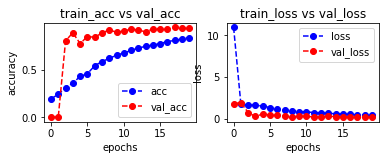

In [38]:
plot_accuracy_loss(cnn_history)

In [39]:
# evaluate loss and accuracy on test dataset
test_loss = cnn_model.evaluate(images_test, labels_test)

94/94 [==============================] - 0s 5ms/step - loss: 0.9882 - accuracy: 0.7260


In [40]:
predictions = cnn_model.predict(images_test) #vector of probabilities
pred_labels = np.argmax(predictions, axis=1) # Chọn xác suất cao nhất
print("Accuracy : {}".format(accuracy_score(labels_test, pred_labels)))

94/94 [==============================] - 0s 4ms/step
Accuracy : 0.726


In [41]:
from sklearn.metrics import classification_report
print(classification_report(labels_test, pred_labels))

              precision    recall  f1-score   support

           0       0.78      0.52      0.62       437
           1       0.81      0.91      0.85       474
           2       0.74      0.69      0.71       553
           3       0.64      0.79      0.70       525
           4       0.65      0.74      0.69       510
           5       0.80      0.70      0.75       501

    accuracy                           0.73      3000
   macro avg       0.74      0.72      0.72      3000
weighted avg       0.73      0.73      0.72      3000



# VGG16 Model

In [12]:
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.models import Model
from keras.layers import Input, Dense, Conv2D, Activation, MaxPooling2D, Flatten

In [13]:
# Initial model for feature extraction
vgg_extract = VGG16(weights='imagenet', include_top=False)
vgg_extract = Model(inputs=vgg_extract.inputs, outputs=vgg_extract.layers[-5].output)

In [16]:
features_train = vgg_extract.predict(images_tstrain)
features_test = vgg_extract.predict(images_tstest)

94/94 [==============================] - 2s 24ms/step


In [17]:
# Modify model for classification with 6 class
vgg_classify = VGG16(weights='imagenet', include_top=False)
input_shape = vgg_classify.layers[-4].get_input_shape_at(0)
layer_input = Input(shape=(9,9,512))

# Build pipeline from choose layer
x = layer_input
for layer in vgg_classify.layers[-4::1]:
    x = layer(x)
x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2,2))(x)
x = Flatten()(x)
x = Dense(100, activation='relu')(x)
x = Dense(6, activation='softmax')(x)

In [18]:
# Create new model from modifed vgg
new_model = Model(layer_input, x)
opt = optimizers.Adam(learning_rate=.0001)
new_model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [19]:
vgg_history = new_model.fit(features_train, labels_train,
                                 shuffle=True,
                                 batch_size=256,
                                 epochs=20,
                                 validation_split=0.1)

Epoch 1/20
50/50 [==============================] - 3s 50ms/step - loss: 1.1073 - accuracy: 0.7031 - val_loss: 0.2078 - val_accuracy: 0.9544
Epoch 2/20
50/50 [==============================] - 2s 42ms/step - loss: 0.3628 - accuracy: 0.8774 - val_loss: 0.1447 - val_accuracy: 0.9687
Epoch 3/20
50/50 [==============================] - 2s 41ms/step - loss: 0.2318 - accuracy: 0.9211 - val_loss: 0.0824 - val_accuracy: 0.9829
Epoch 4/20
50/50 [==============================] - 2s 41ms/step - loss: 0.1441 - accuracy: 0.9529 - val_loss: 0.0761 - val_accuracy: 0.9850
Epoch 5/20
50/50 [==============================] - 2s 41ms/step - loss: 0.0911 - accuracy: 0.9743 - val_loss: 0.0964 - val_accuracy: 0.9829
Epoch 6/20
50/50 [==============================] - 2s 41ms/step - loss: 0.0522 - accuracy: 0.9869 - val_loss: 0.0863 - val_accuracy: 0.9815
Epoch 7/20
50/50 [==============================] - 2s 41ms/step - loss: 0.0294 - accuracy: 0.9942 - val_loss: 0.0874 - val_accuracy: 0.9822
Epoch 8/20
50

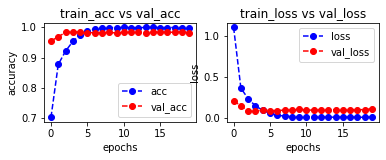

In [22]:
plot_accuracy_loss(vgg_history)

In [25]:
predictions = new_model.predict(features_test)
pred_labels = np.argmax(predictions, axis = 1)
print("Accuracy : {}".format(accuracy_score(labels_test, pred_labels)))

94/94 [==============================] - 0s 4ms/step
Accuracy : 0.9043333333333333


In [28]:
print(classification_report(labels_test, pred_labels))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       437
           1       0.98      0.98      0.98       474
           2       0.85      0.85      0.85       553
           3       0.87      0.83      0.85       525
           4       0.90      0.95      0.92       510
           5       0.94      0.92      0.93       501

    accuracy                           0.90      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.90      0.90      0.90      3000

